# 02. Exposure-controlled models

Three Whisper-base models were fine-tuned from `openai/whisper-base` with one recipe (three epochs, batch 32,
AdamW 1e-5, 500 warm-up steps, bf16, seed 20260919) on an RTX 5080. Training code: `src/training/train.py`
(M0) and `src/training/train_exposure.py` (M1, M2). This notebook reads the training logs written during those
runs and the hashes of the evaluated weights.

In [1]:
import sys, json, gzip, collections
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src" / "analysis"))
import numpy as np
import stats as S
import matplotlib.pyplot as plt

In [2]:
logs = {m: [json.loads(l) for l in open(ROOT / f"results/train_log_{m}.jsonl")] for m in ["M0", "M1", "M2"]}
print(f"{'model':5s} {'clips':>8s} {'reciters':>8s} {'steps':>6s} {'selected':>8s} {'val WER':>8s}")
for m, ev in logs.items():
    data = next(e for e in ev if e["event"] == "data"); start = next(e for e in ev if e["event"] == "start")
    best = [e for e in ev if e["event"] == "saved_best"][-1]
    print(f"{m:5s} {data['train']:8,d} {data['train_reciters']:8d} {start['total_steps']:6d} {best['step']:8d} {best['val_wer']:8.4f}")

model    clips reciters  steps selected  val WER
M0     105,026       24   9846     9846   0.0130
M1     151,761       33  14226    14000   0.0086
M2     152,276       33  14274    14000   0.0095


**Protocol deviation (disclosed).** The exposure protocol fixed 9,846 optimizer steps for all three models.
M1 and M2 instead ran the full three epochs (the step counts above), because the training script sets the
length in epochs and no step cap was passed. M1 and M2 remain matched to each other (same steps, same selection
step), which is the comparison the exposure tests rely on; M0 differs from them in training length as well as
data. See `protocols/PROTOCOL_exposure.md`, Amendment 3.

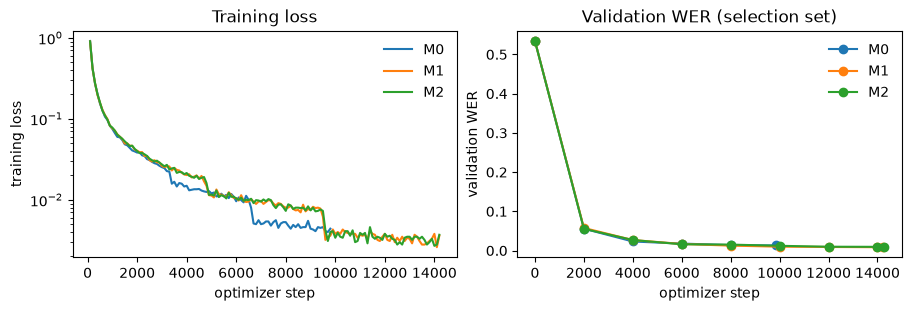

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), layout="constrained")
for m, ev in logs.items():
    tr = [e for e in ev if e["event"] == "train"]; va = [e for e in ev if e["event"] == "eval"]
    axes[0].plot([e["step"] for e in tr], [e["loss"] for e in tr], label=m)
    axes[1].plot([e["step"] for e in va], [e["val_wer"] for e in va], "o-", label=m)
axes[0].set(xlabel="optimizer step", ylabel="training loss", yscale="log", title="Training loss")
axes[1].set(xlabel="optimizer step", ylabel="validation WER", title="Validation WER (selection set)")
for ax in axes: ax.legend(frameon=False)
plt.show()

## Weights evaluated
Each evaluation run recorded the SHA-256 of the weight files it loaded.

In [4]:
for run in ["tarteel", "M0", "M1", "M2"]:
    swap = json.loads((ROOT / f"results/{run}/SWAP.json").read_text())
    weights = {k: v[:16] for k, v in swap["sha256"].items() if k.endswith((".bin", ".safetensors"))}
    print(f"{run:8s}", weights)

tarteel  {'pytorch_model.bin': 'ec75894993a4570a', 'training_args.bin': '91c6a8514089dbd3'}
M0       {'model.safetensors': 'f86069a9e16845cd'}
M1       {'model.safetensors': '78e187b7dfe25375'}
M2       {'model.safetensors': 'e6992fe1fb7d6f5f'}
